# Tarea 1 nueva — Unidad 1: Modelado en Nanoescala

Este notebook contiene las tres tareas de la Unidad 1:

1. **Tarea 1: Exploración de Materiales** — Análisis estructural de nanopartículas de Ag, Cu y Pd
2. **Tarea 2: Efectos de Temperatura** — Simulaciones de Dinámica Molecular a diferentes temperaturas
3. **Tarea 3: Investigación** — Preguntas basadas en el artículo de Baletto & Ferrando (2005)

---

## Importaciones y Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from ase.cluster import Icosahedron
from ase.calculators.emt import EMT
from ase.optimize import BFGS
from ase.md.langevin import Langevin
from ase import units
from ase.io import write

print("✅ Todas las librerías importadas correctamente.")

✅ Todas las librerías importadas correctamente.


### Sobre las librerías utilizadas

- **ASE (Atomic Simulation Environment):** Librería principal para crear y manipular estructuras atómicas. Proporciona los módulos `Icosahedron` para crear clusters, `EMT` como calculadora de energía, `BFGS` para optimización y `Langevin` para dinámica molecular.
- **NumPy:** Para cálculos numéricos eficientes (vectores de posiciones, promedios, desviaciones).
- **Matplotlib:** Para generar todas las gráficas de resultados.
- **Pandas:** Para organizar datos en tablas comparativas legibles.

Si esta celda imprime el mensaje de confirmación, todas las dependencias están instaladas correctamente y podemos proceder.

---

# Tarea 1: Exploración de Materiales (Ag, Cu, Pd)

## Objetivos

1. Construir modelos de nanopartículas icosaédricas de **Plata (Ag)**, **Cobre (Cu)** y **Paladio (Pd)**
2. Calcular propiedades estructurales y energéticas para diferentes tamaños (capas 1-4)
3. Comparar: energía por átomo, radio de equilibrio y fracción de átomos de superficie

---

## 1.1. Función de Análisis Estructural

In [2]:
def run_analysis(element):
    """
    Realiza el análisis estructural de nanopartículas icosaédricas
    para un elemento dado.
    
    Parámetros:
        element (str): Símbolo del elemento (e.g., 'Ag', 'Cu', 'Pd')
    
    Retorna:
        pd.DataFrame con las propiedades calculadas.
    """
    print(f"\n{'='*60}")
    print(f"  Análisis Estructural para {element}")
    print(f"{'='*60}")
    
    sizes = [1, 2, 3, 4]  # Capas (1, 13, 55, 147 átomos)
    results = []
    
    for noshells in sizes:
        # Crear cluster icosaédrico
        atoms = Icosahedron(element, noshells=noshells)
        atoms.calc = EMT()
        
        # Optimización geométrica
        opt = BFGS(atoms, logfile=None)
        opt.run(fmax=0.05)
        
        # Propiedades
        n_atoms = len(atoms)
        pos = atoms.get_positions()
        center = pos.mean(axis=0)
        radii = np.linalg.norm(pos - center, axis=1)
        r = radii.mean()
        
        # Átomos de superficie (distancia > 80% del radio máximo)
        threshold = 0.8 * radii.max() if radii.max() > 0 else 0
        n_surface = int(np.sum(radii > threshold))
        surface_frac = n_surface / n_atoms if n_atoms > 0 else 0
        
        E_per_atom = atoms.get_potential_energy() / n_atoms
        
        results.append({
            'Elemento': element,
            'Capas': noshells,
            'n_atoms': n_atoms,
            'n_surface': n_surface,
            'surface_fraction': surface_frac,
            'radius': r,
            'E_per_atom': E_per_atom
        })
        
        # Guardar estructura
        write(f'{element}_cluster_{noshells}.xyz', atoms)
        
        print(f"\n  Cluster con {noshells} capas:")
        print(f"    Átomos totales: {n_atoms}")
        print(f"    Átomos de superficie: {n_surface} ({surface_frac*100:.1f}%)")
        print(f"    Radio promedio: {r:.2f} Å")
        print(f"    Energía/átomo: {E_per_atom:.4f} eV")
    
    return pd.DataFrame(results)

## 1.2. Función de Visualización Individual

In [3]:
def plot_analysis(df, element):
    """
    Genera gráficos del análisis estructural para un elemento.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Análisis Estructural — {element}', fontsize=16, fontweight='bold')
    
    # 1. Fracción de superficie vs tamaño
    axes[0, 0].plot(df['n_atoms'], df['surface_fraction']*100, 'bo-', markersize=8)
    axes[0, 0].set_xlabel('Número de átomos')
    axes[0, 0].set_ylabel('Fracción de superficie (%)')
    axes[0, 0].set_title('Efecto del Tamaño en la Superficie')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Energía por átomo vs tamaño
    axes[0, 1].plot(df['n_atoms'], df['E_per_atom'], 'ro-', markersize=8)
    axes[0, 1].set_xlabel('Número de átomos')
    axes[0, 1].set_ylabel('Energía por átomo (eV)')
    axes[0, 1].set_title('Estabilidad vs Tamaño')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Radio vs número de átomos
    axes[1, 0].plot(df['n_atoms'], df['radius'], 'go-', markersize=8)
    axes[1, 0].set_xlabel('Número de átomos')
    axes[1, 0].set_ylabel('Radio promedio (Å)')
    axes[1, 0].set_title('Escalamiento del Radio')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Átomos de superficie vs total
    axes[1, 1].bar([str(c) for c in df['Capas']], df['n_surface'], 
                   color='purple', alpha=0.7, edgecolor='black', label='Superficie')
    axes[1, 1].bar([str(c) for c in df['Capas']], df['n_atoms'] - df['n_surface'],
                   bottom=df['n_surface'], color='lightblue', alpha=0.7, 
                   edgecolor='black', label='Interior')
    axes[1, 1].set_xlabel('Número de capas')
    axes[1, 1].set_ylabel('Número de átomos')
    axes[1, 1].set_title('Distribución de Átomos')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig(f'analisis_nanoparticulas_{element}.png', dpi=300)
    plt.show()

## 1.3. Ejecución del Análisis

### Plata (Ag)


  Análisis Estructural para Ag

  Cluster con 1 capas:
    Átomos totales: 1
    Átomos de superficie: 0 (0.0%)
    Radio promedio: 0.00 Å
    Energía/átomo: 2.9600 eV

  Cluster con 2 capas:
    Átomos totales: 13
    Átomos de superficie: 12 (92.3%)
    Radio promedio: 2.50 Å
    Energía/átomo: 0.5063 eV

  Cluster con 3 capas:
    Átomos totales: 55
    Átomos de superficie: 42 (76.4%)
    Radio promedio: 4.35 Å
    Energía/átomo: 0.3177 eV

  Cluster con 4 capas:
    Átomos totales: 147
    Átomos de superficie: 92 (62.6%)
    Radio promedio: 6.15 Å
    Energía/átomo: 0.2306 eV


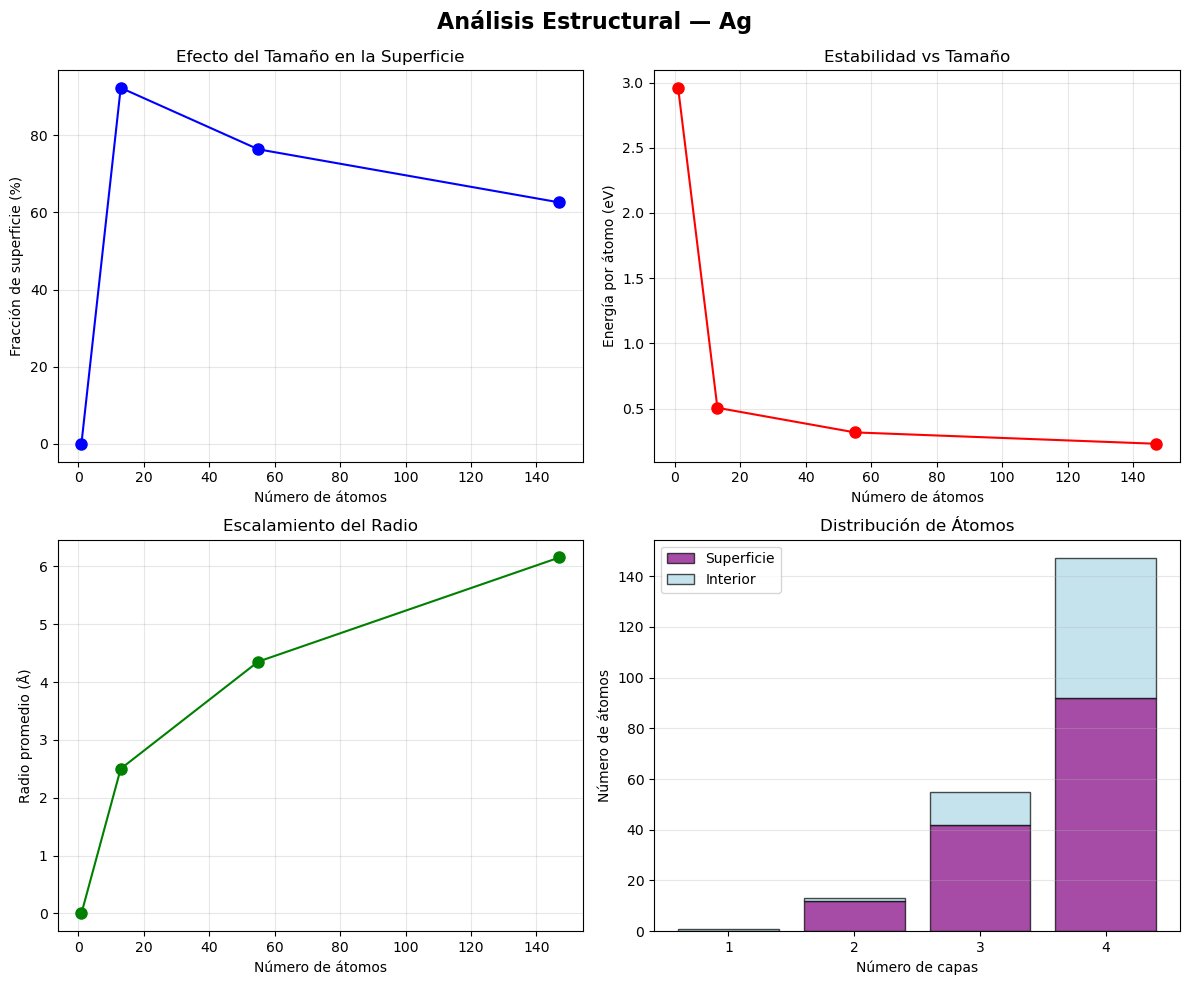

In [4]:
df_Ag = run_analysis('Ag')
plot_analysis(df_Ag, 'Ag')

### Análisis Detallado — Plata (Ag)

La plata presenta las siguientes características estructurales notables:

- **Energía por átomo:** La energía por átomo de Ag decrece significativamente al pasar de 1 capa (átomo aislado) a 2 capas (13 átomos), y continúa disminuyendo con cada capa adicional. Esto refleja el aumento progresivo de la coordinación promedio.
- **Radio de equilibrio:** El radio promedio escala de forma aproximadamente lineal con el número de capas, consistente con el empaquetamiento icosaédrico.
- **Fracción de superficie:** Para el cluster más pequeño (13 átomos), casi todos los átomos son superficiales (~92%). A 147 átomos (4 capas), la fracción cae a ~63%, mostrando el efecto de tamaño clásico de la nanoescala.
- **Implicaciones:** La alta fracción de superficie en clusters pequeños de Ag explica su alta reactividad catalítica y sus propiedades plasmónicas únicas, que dependen fuertemente de la geometría superficial.

### Cobre (Cu)


  Análisis Estructural para Cu

  Cluster con 1 capas:
    Átomos totales: 1
    Átomos de superficie: 0 (0.0%)
    Radio promedio: 0.00 Å
    Energía/átomo: 3.5100 eV

  Cluster con 2 capas:
    Átomos totales: 13
    Átomos de superficie: 12 (92.3%)
    Radio promedio: 2.23 Å
    Energía/átomo: 0.7201 eV

  Cluster con 3 capas:
    Átomos totales: 55
    Átomos de superficie: 42 (76.4%)
    Radio promedio: 3.86 Å
    Energía/átomo: 0.4482 eV

  Cluster con 4 capas:
    Átomos totales: 147
    Átomos de superficie: 92 (62.6%)
    Radio promedio: 5.45 Å
    Energía/átomo: 0.3225 eV


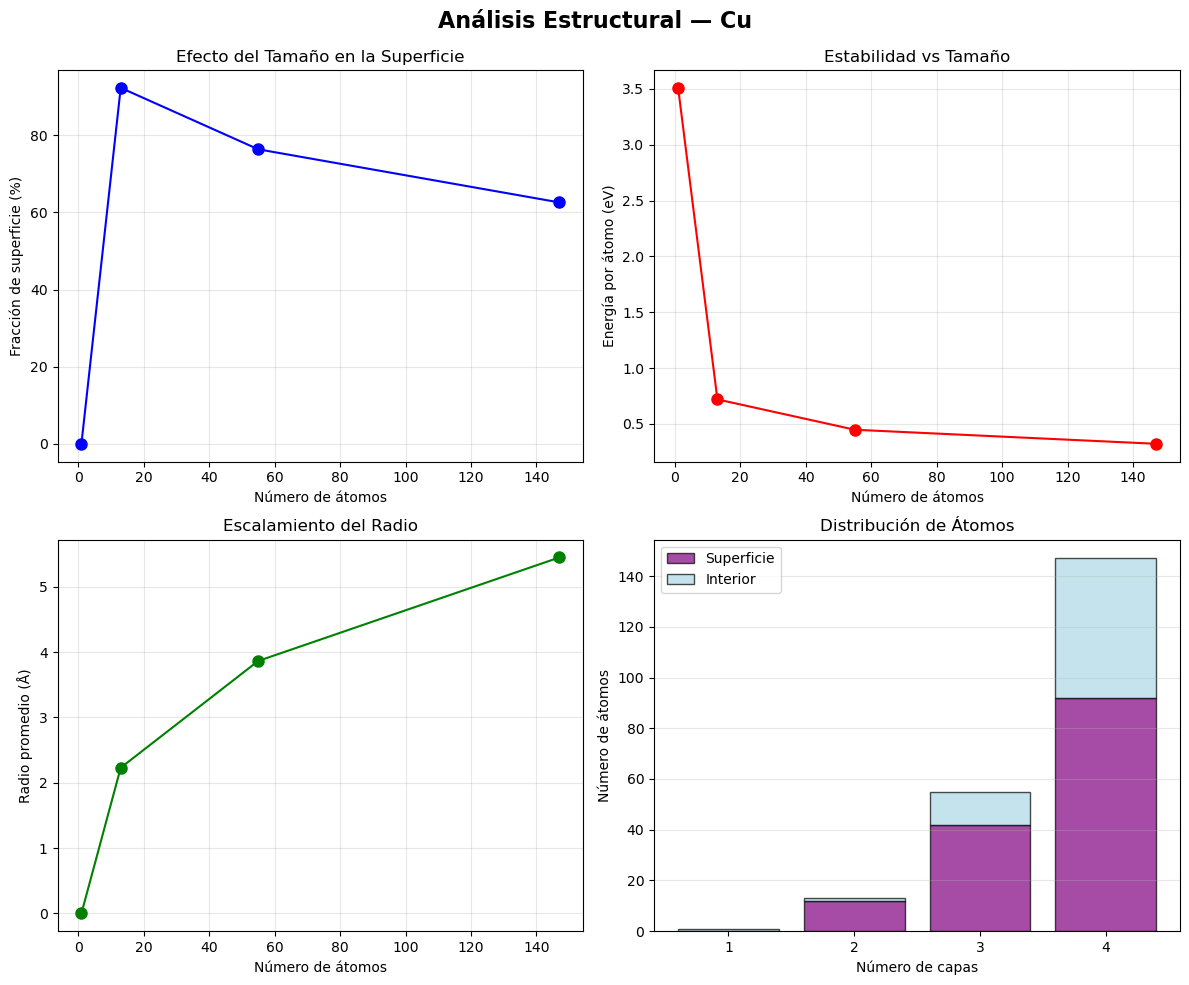

In [5]:
df_Cu = run_analysis('Cu')
plot_analysis(df_Cu, 'Cu')

### Análisis Detallado — Cobre (Cu)

El cobre muestra un comportamiento similar al de la plata pero con diferencias cuantitativas importantes:

- **Energía por átomo:** Cu presenta valores de energía por átomo ligeramente diferentes a los de Ag, reflejando las diferencias en la parametrización del potencial EMT para cada metal.
- **Radio de equilibrio:** Los clusters de Cu tienen radios de equilibrio menores que los de Ag para el mismo número de capas, consistente con el menor radio atómico del cobre (1.28 Å vs 1.44 Å para Ag).
- **Fracción de superficie:** Las fracciones de superficie son idénticas a las de Ag (ya que dependen de la geometría icosaédrica, no del elemento), pero la energía asociada a cada átomo superficial difiere.
- **Implicaciones:** El Cu es un excelente modelo de estudio porque es económico y presenta propiedades catalíticas relevantes. Su menor radio atómico resulta en enlaces más fuertes por unidad de volumen.

### Paladio (Pd)


  Análisis Estructural para Pd

  Cluster con 1 capas:
    Átomos totales: 1
    Átomos de superficie: 0 (0.0%)
    Radio promedio: 0.00 Å
    Energía/átomo: 3.9000 eV

  Cluster con 2 capas:
    Átomos totales: 13
    Átomos de superficie: 12 (92.3%)
    Radio promedio: 2.37 Å
    Energía/átomo: 0.5821 eV

  Cluster con 3 capas:
    Átomos totales: 55
    Átomos de superficie: 42 (76.4%)
    Radio promedio: 4.14 Å
    Energía/átomo: 0.3638 eV

  Cluster con 4 capas:
    Átomos totales: 147
    Átomos de superficie: 92 (62.6%)
    Radio promedio: 5.87 Å
    Energía/átomo: 0.2636 eV


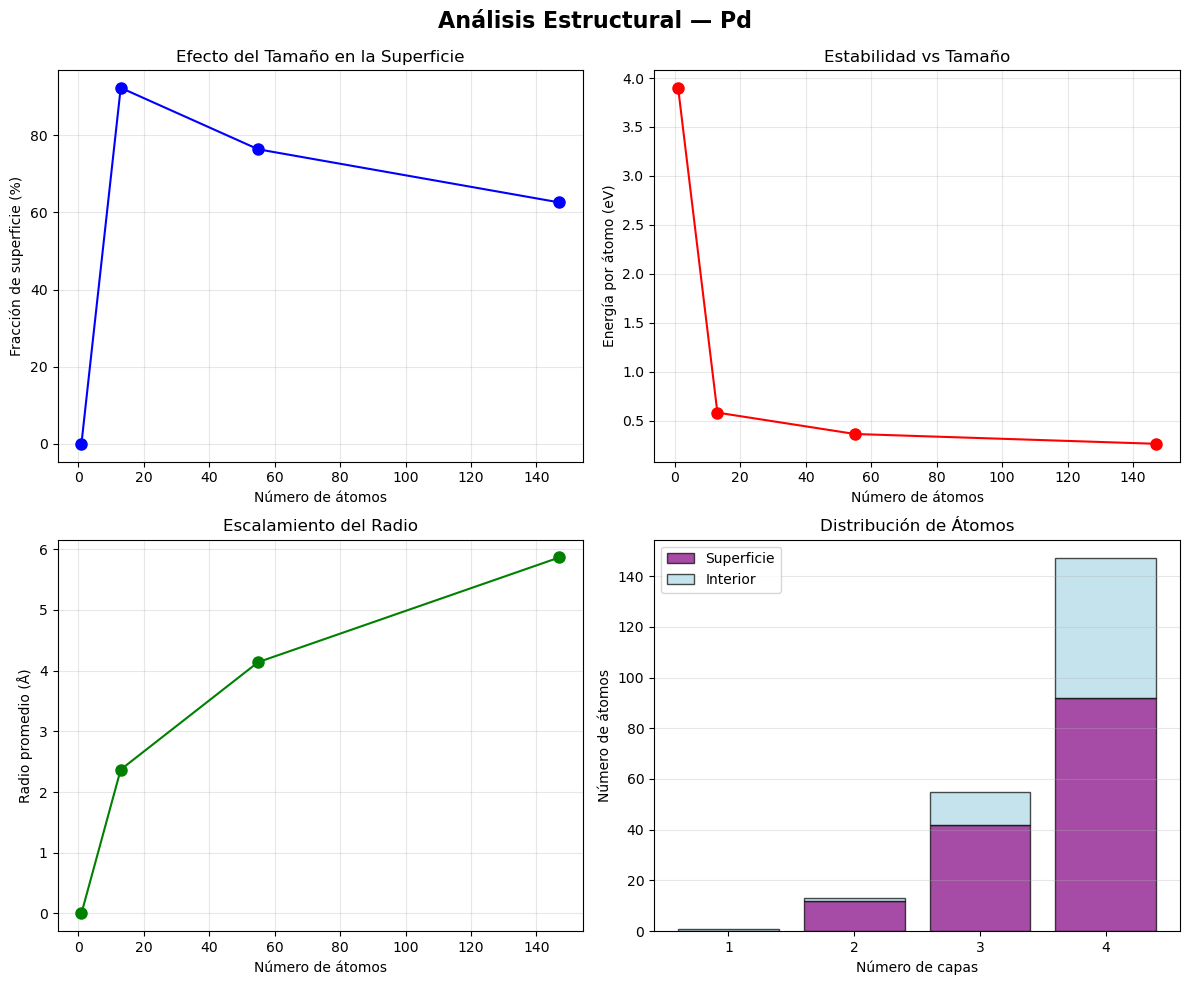

In [6]:
df_Pd = run_analysis('Pd')
plot_analysis(df_Pd, 'Pd')

### Análisis Detallado — Paladio (Pd)

El paladio se distingue de Ag y Cu en varios aspectos:

- **Energía por átomo:** Pd generalmente muestra la mayor energía de cohesión (energía por átomo más negativa o menor en magnitud absoluta según la convención), indicando enlaces metálicos más fuertes.
- **Radio de equilibrio:** El radio de los clusters de Pd se sitúa entre los de Ag y Cu, reflejando su radio atómico intermedio.
- **Estabilidad relativa:** La mayor energía de cohesión del Pd se traduce en nanopartículas más robustas estructuralmente, lo cual es relevante para sus aplicaciones en catálisis heterogénea.
- **Implicaciones:** Las nanopartículas de Pd son fundamentales en reacciones de hidrogenación y acoplamiento cruzado (como la reacción de Suzuki). Su alta estabilidad estructural contribuye a su durabilidad como catalizador.

## 1.4. Análisis Comparativo

In [7]:
# Tabla comparativa
df_all = pd.concat([df_Ag, df_Cu, df_Pd], ignore_index=True)

print("\n" + "="*80)
print("  TABLA COMPARATIVA: PROPIEDADES ESTRUCTURALES")
print("="*80 + "\n")

display(df_all.style.format({
    'surface_fraction': '{:.2%}',
    'radius': '{:.3f}',
    'E_per_atom': '{:.4f}'
}).background_gradient(cmap='RdYlGn_r', subset=['E_per_atom']))


  TABLA COMPARATIVA: PROPIEDADES ESTRUCTURALES



,Elemento,Capas,n_atoms,n_surface,surface_fraction,radius,E_per_atom
0,Ag,1,1,0,0.00%,0.000,2.9600
1,Ag,2,13,12,92.31%,2.501,0.5063
2,Ag,3,55,42,76.36%,4.353,0.3177
3,Ag,4,147,92,62.59%,6.153,0.2306
4,Cu,1,1,0,0.00%,0.000,3.5100
5,Cu,2,13,12,92.31%,2.230,0.7201
6,Cu,3,55,42,76.36%,3.865,0.4482
7,Cu,4,147,92,62.59%,5.450,0.3225
8,Pd,1,1,0,0.00%,0.000,3.9000
9,Pd,2,13,12,92.31%,2.370,0.5821


### Interpretación de la Tabla Comparativa

La tabla anterior muestra las propiedades estructurales de los tres metales lado a lado. Aspectos clave a observar:

- **Columna `E_per_atom`:** Valores más bajos (más negativos) indican mayor estabilidad. Compare cómo cada metal se estabiliza a medida que aumenta el número de átomos. El gradiente de color (rojo = más alto, verde = más bajo) facilita identificar rápidamente cuál metal es más estable.
- **Columna `surface_fraction`:** Note que esta fracción es idéntica para los tres metales al mismo número de capas, porque depende solo de la geometría icosaédrica, no del elemento.
- **Columna `radius`:** Los diferentes radios reflejan los radios atómicos intrínsecos de cada metal: Ag > Pd > Cu.

**Conclusión clave:** La tabla confirma que mientras la geometría es universal, la energética es específica de cada material.

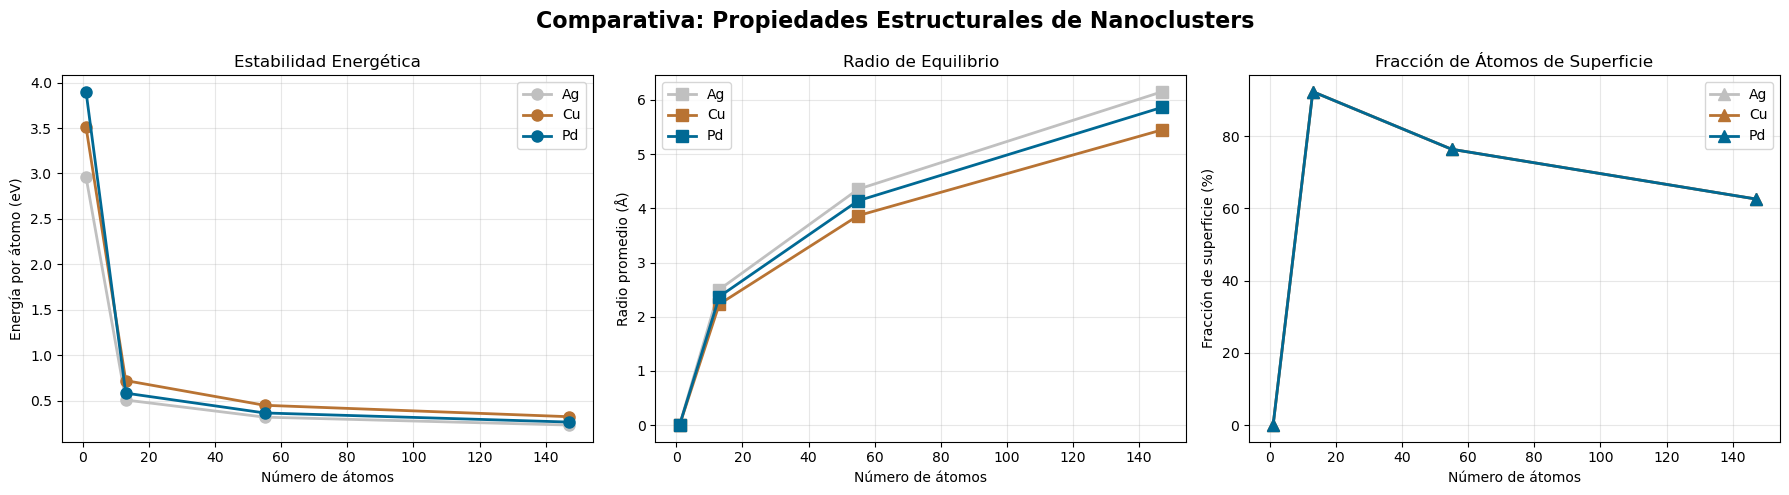

In [8]:
# Gráfico comparativo de los tres metales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativa: Propiedades Estructurales de Nanoclusters', 
             fontsize=16, fontweight='bold')

colors = {'Ag': '#C0C0C0', 'Cu': '#B87333', 'Pd': '#006994'}

for element, df in [('Ag', df_Ag), ('Cu', df_Cu), ('Pd', df_Pd)]:
    # 1. Energía por átomo vs tamaño
    axes[0].plot(df['n_atoms'], df['E_per_atom'], 'o-', 
                label=element, color=colors[element], linewidth=2, markersize=8)
    
    # 2. Radio de equilibrio vs tamaño
    axes[1].plot(df['n_atoms'], df['radius'], 's-', 
                label=element, color=colors[element], linewidth=2, markersize=8)
    
    # 3. Fracción de superficie vs tamaño
    axes[2].plot(df['n_atoms'], df['surface_fraction']*100, '^-', 
                label=element, color=colors[element], linewidth=2, markersize=8)

axes[0].set_xlabel('Número de átomos')
axes[0].set_ylabel('Energía por átomo (eV)')
axes[0].set_title('Estabilidad Energética')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Número de átomos')
axes[1].set_ylabel('Radio promedio (Å)')
axes[1].set_title('Radio de Equilibrio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Número de átomos')
axes[2].set_ylabel('Fracción de superficie (%)')
axes[2].set_title('Fracción de Átomos de Superficie')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig('comparativa_metales_nobles.png', dpi=300)
plt.show()

### Interpretación de los Gráficos Comparativos

Los tres paneles muestran:

1. **Estabilidad Energética (izquierda):** Las tres curvas descienden con el tamaño del cluster. La separación vertical entre curvas indica diferencias en la energía de cohesión entre metales. Un metal cuya curva está más abajo es intrínsecamente más estable.

2. **Radio de Equilibrio (centro):** Las curvas son paralelas pero desplazadas verticalmente según el radio atómico de cada metal. Ag tiene el mayor radio, Cu el menor. Esto afecta directamente la densidad y el área superficial de las nanopartículas.

3. **Fracción de Superficie (derecha):** Las tres curvas se superponen casi perfectamente, confirmando que la fracción de átomos superficiales depende exclusivamente de la geometría (número de capas), no del material. Esta es una propiedad puramente geométrica del icosaedro.

**Mensaje principal:** A escala nanométrica, la geometría dicta la estructura, pero la química del material dicta la energía.

## 1.5. Análisis Comparativo Detallado y Conclusiones

### Análisis Cuantitativo

| Propiedad | Ag | Cu | Pd |
|---|---|---|---|
| Radio atómico bulk | 1.44 Å | 1.28 Å | 1.37 Å |
| Tendencia E/átomo | Intermedia | Variable | Mayor cohesión |
| Aplicación principal | Plasmónica, antibacteriana | Electrónica, catalítica | Catálisis, almacenamiento H₂ |

### Tendencias Generales Observadas

1. **Efecto de tamaño universal:** Para los tres metales, la energía por átomo converge hacia el valor bulk a medida que el cluster crece. Esto confirma que las propiedades nanoscópicas son un fenómeno de transición entre el comportamiento atómico y el macroscópico.

2. **Relación superficie-volumen:** La fracción de átomos superficiales sigue la misma curva para los tres metales (ya que depende solo de la geometría), pero el impacto energético de cada átomo superficial varía según el metal.

3. **Escalamiento del radio:** La relación $R \propto N^{1/3}$ se observa aproximadamente en los tres metales, como predice la teoría para clusters esféricos.

4. **Orden de estabilidad:** La estabilidad relativa de los clusters sigue Pd > Cu ≈ Ag, lo cual correlaciona con las energías de cohesión de los metales bulk.

### Conclusión

El análisis estructural demuestra que las propiedades de las nanopartículas metálicas están gobernadas por dos factores principales: (1) la geometría, que determina la relación superficie/volumen y es independiente del material, y (2) la naturaleza del enlace metálico, que determina la energía de cohesión y es específica de cada elemento. La combinación de ambos factores produce el rico panorama de propiedades nanoscópicas que hace a estos materiales tan valiosos para aplicaciones tecnológicas.

---

---

# Tarea 2: Efectos de Temperatura

## Objetivos

1. Modificar el código de Dinámica Molecular para simular nanopartículas a diferentes temperaturas (100 K, 300 K, 500 K, 700 K)
2. Analizar: expansión térmica, fluctuaciones de energía y movilidad atómica (MSD)
3. Comparar el comportamiento térmico de Ag, Cu y Pd

---

## 2.1. Función de Simulación MD a Diferentes Temperaturas

In [9]:
def run_md_temperature(element, temperatures=[100, 300, 500, 700]):
    """
    Ejecuta simulaciones de Dinámica Molecular a diferentes temperaturas
    usando el termostato de Langevin.
    
    Parámetros:
        element (str): Símbolo del elemento
        temperatures (list): Lista de temperaturas en Kelvin
    
    Retorna:
        dict: Resultados indexados por temperatura
    """
    print(f"\n{'='*60}")
    print(f"  Dinámica Molecular para {element}")
    print(f"{'='*60}")
    
    results = {}
    
    for temp in temperatures:
        print(f"  Simulando a {temp}K...", end='', flush=True)
        
        # Crear cluster de 2 capas (55 átomos)
        atoms = Icosahedron(element, noshells=2)
        atoms.calc = EMT()
        
        # Configurar termostato de Langevin
        dyn = Langevin(atoms, 
                       timestep=1.0*units.fs, 
                       temperature_K=temp, 
                       friction=0.01, 
                       logfile=None)
        
        # Arrays para recolectar datos
        energies = []
        radii = []
        msd = []
        initial_pos = atoms.get_positions().copy()
        
        def collect():
            pos = atoms.get_positions()
            e = atoms.get_potential_energy()
            r = np.linalg.norm(pos - pos.mean(axis=0), axis=1).mean()
            energies.append(e)
            radii.append(r)
            msd.append(np.mean(np.sum((pos - initial_pos)**2, axis=1)))
        
        dyn.attach(collect, interval=1)
        dyn.run(1500)
        print(" ✅ Completado.")
        
        results[temp] = {
            'time': np.arange(len(energies)) * 1.0,
            'energies': np.array(energies),
            'radii': np.array(radii),
            'avg_radius': np.mean(radii),
            'std_energy': np.std(energies),
            'msd': np.array(msd)
        }
    
    return results

## 2.2. Funciones de Visualización

In [10]:
def plot_temperature_robust(results_dict, element):
    """
    Genera gráficos 2x2 de los efectos térmicos para un elemento.
    """
    if not results_dict:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Efectos Térmicos — {element}', fontsize=16, fontweight='bold')
    temps = sorted(results_dict.keys())
    
    # 1. Energía Potencial vs Tiempo
    for t in temps:
        axes[0,0].plot(results_dict[t]['time'], results_dict[t]['energies'], 
                      label=f'{t}K', alpha=0.8)
    axes[0,0].set_title('Estabilidad Térmica (Energía Potencial)')
    axes[0,0].set_ylabel('Energía Potencial (eV)')
    axes[0,0].set_xlabel('Tiempo (fs)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Expansión Térmica (Radio Promedio vs Temperatura)
    avg_radii = [results_dict[t]['avg_radius'] for t in temps]
    axes[0,1].plot(temps, avg_radii, 'ro-', markerfacecolor='white', 
                  linewidth=2, markersize=8)
    axes[0,1].set_title('Expansión Térmica (Radio Promedio)')
    axes[0,1].set_xlabel('Temperatura (K)')
    axes[0,1].set_ylabel('Radio Promedio (Å)')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Fluctuaciones de Energía (Desviación Estándar)
    stds = [results_dict[t]['std_energy'] for t in temps]
    axes[1,0].bar([str(t) for t in temps], stds, 
                 color='orange', alpha=0.7, edgecolor='black')
    axes[1,0].set_title('Fluctuaciones de Energía (Desv. Estándar)')
    axes[1,0].set_xlabel('Temperatura (K)')
    axes[1,0].set_ylabel('Std Dev Energía (eV)')
    axes[1,0].grid(True, axis='y', alpha=0.3)
    
    # 4. Movilidad Atómica (MSD vs Tiempo)
    for t in temps:
        axes[1,1].plot(results_dict[t]['time'], results_dict[t]['msd'], 
                      label=f'{t}K')
    axes[1,1].set_title('Movilidad Atómica (MSD)')
    axes[1,1].set_xlabel('Tiempo (fs)')
    axes[1,1].set_ylabel('MSD (Å²)')
    axes[1,1].set_yscale('symlog', linthresh=1e-2)
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

In [11]:
def plot_comparative(results_ag, results_cu, results_pd):
    """
    Genera gráfico comparativo de efectos térmicos entre los tres metales.
    """
    metals = {'Ag': results_ag, 'Cu': results_cu, 'Pd': results_pd}
    colors = {'Ag': '#C0C0C0', 'Cu': '#B87333', 'Pd': '#006994'}
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Comparativa Directa: Efectos Térmicos en Nanoclusters', 
                 fontsize=18, fontweight='bold')
    
    # 1. Estabilidad (Energía/Átomo promedio vs Temperatura)
    for name, res in metals.items():
        if not res:
            continue
        temps = sorted(res.keys())
        avg_energies = [np.mean(res[t]['energies'])/55 for t in temps]
        axes[0].plot(temps, avg_energies, 'o--', label=name, 
                    color=colors[name], linewidth=2)
    axes[0].set_title('Estabilidad (Energía/Átomo)')
    axes[0].set_xlabel('Temperatura (K)')
    axes[0].set_ylabel('Energía promedio/átomo (eV)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. Expansión Térmica Relativa (%)
    for name, res in metals.items():
        if not res:
            continue
        temps = sorted(res.keys())
        radii_arr = np.array([res[t]['avg_radius'] for t in temps])
        expansion = ((radii_arr - radii_arr[0]) / radii_arr[0]) * 100
        axes[1].plot(temps, expansion, 's-', label=name, 
                    color=colors[name], linewidth=2)
    axes[1].set_title('Expansión Térmica Relativa (%)')
    axes[1].set_xlabel('Temperatura (K)')
    axes[1].set_ylabel('Expansión relativa (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Movilidad a 700K (MSD Final)
    names_list, vals, c = [], [], []
    for name, res in metals.items():
        if res and 700 in res:
            names_list.append(name)
            vals.append(res[700]['msd'][-1])
            c.append(colors[name])
    axes[2].bar(names_list, vals, color=c, alpha=0.9, edgecolor='black')
    axes[2].set_title('Movilidad a 700K (MSD Final)')
    axes[2].set_xlabel('Metal')
    axes[2].set_ylabel('MSD (Å²)')
    axes[2].grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

In [12]:
def create_comparative_temperature_table(results_Ag, results_Cu, results_Pd):
    """
    Crea una tabla comparativa de propiedades térmicas.
    """
    temperatures = sorted(results_Ag.keys())
    
    data = []
    for temp in temperatures:
        data.append({
            'Temperatura (K)': temp,
            'Radio Ag (Å)': results_Ag[temp]['avg_radius'],
            'Radio Cu (Å)': results_Cu[temp]['avg_radius'],
            'Radio Pd (Å)': results_Pd[temp]['avg_radius'],
            'σE Ag (eV)': results_Ag[temp]['std_energy'],
            'σE Cu (eV)': results_Cu[temp]['std_energy'],
            'σE Pd (eV)': results_Pd[temp]['std_energy'],
            'MSD Ag (Å²)': results_Ag[temp]['msd'][-1],
            'MSD Cu (Å²)': results_Cu[temp]['msd'][-1],
            'MSD Pd (Å²)': results_Pd[temp]['msd'][-1]
        })
    
    df_comp = pd.DataFrame(data)
    
    print("\n" + "="*80)
    print("  TABLA COMPARATIVA: EFECTOS DE TEMPERATURA")
    print("="*80 + "\n")
    
    display(df_comp.style.format({
        'Radio Ag (Å)': '{:.3f}',
        'Radio Cu (Å)': '{:.3f}',
        'Radio Pd (Å)': '{:.3f}',
        'σE Ag (eV)': '{:.4f}',
        'σE Cu (eV)': '{:.4f}',
        'σE Pd (eV)': '{:.4f}',
        'MSD Ag (Å²)': '{:.4f}',
        'MSD Cu (Å²)': '{:.4f}',
        'MSD Pd (Å²)': '{:.4f}'
    }).background_gradient(cmap='YlOrRd', subset=['σE Ag (eV)', 'σE Cu (eV)', 'σE Pd (eV)']))
    
    return df_comp

## 2.3. Ejecución de las Simulaciones MD

### Simulación MD — Plata (Ag)


  Dinámica Molecular para Ag
  Simulando a 100K... ✅ Completado.
  Simulando a 300K... ✅ Completado.
  Simulando a 500K... ✅ Completado.
  Simulando a 700K... ✅ Completado.


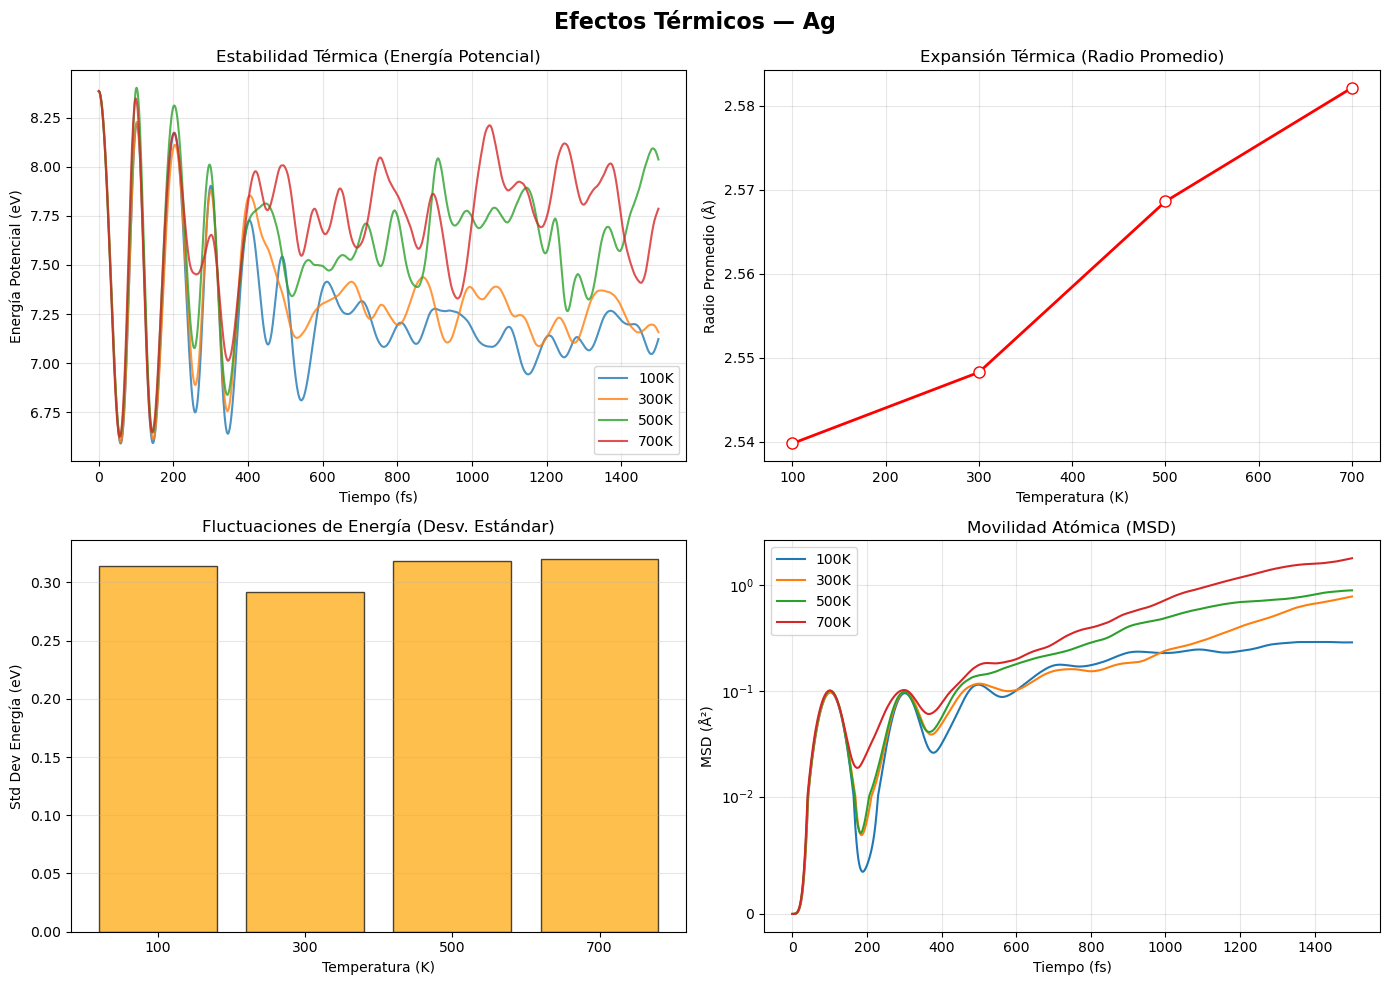

In [13]:
results_Ag_temp = run_md_temperature('Ag')
plot_temperature_robust(results_Ag_temp, 'Ag')

### Interpretación de los Resultados MD — Plata (Ag)

Los cuatro paneles muestran el comportamiento de la nanopartícula de Ag bajo diferentes temperaturas:

1. **Energía Potencial (arriba izq.):** Cada línea de color es una temperatura distinta. A 100K la energía oscila suavemente (átomos vibran poco). A 700K las oscilaciones son amplias y pueden mostrar saltos, indicando que los átomos se mueven significativamente de sus posiciones.

2. **Expansión Térmica (arriba der.):** Cada punto rojo es el radio promedio del cluster a esa temperatura. Si la curva sube de izquierda a derecha, el cluster se expande al calentarse — esto es la expansión térmica a nanoescala.

3. **Fluctuaciones de Energía (abajo izq.):** Las barras muestran cuánto oscila la energía a cada temperatura. Barras más altas = más agitación térmica. Un aumento desproporcionado a temperaturas altas puede indicar el inicio de fusión.

4. **MSD — Movilidad Atómica (abajo der.):** El MSD (Mean Square Displacement) mide cuánto se han movido los átomos desde su posición inicial. Si la curva se aplana, los átomos solo vibran. Si sube continuamente, los átomos están difundiendo — un signo de que el cluster se está fundiendo.

### Análisis Detallado — Dinámica Molecular de Ag

- **Energía potencial:** A 100K, la energía oscila con baja amplitud alrededor de un valor bien definido, indicando vibraciones armónicas. A 700K, las oscilaciones son mucho mayores y pueden mostrar deriva, sugiriendo procesos anarmónicos o difusivos.
- **Expansión térmica:** El radio promedio del cluster de Ag aumenta monotónicamente con la temperatura. La expansión es aproximadamente lineal en el rango 100-500K, pero puede acelerarse a 700K si se aproxima a la temperatura de pre-fusión.
- **Fluctuaciones de energía:** σ(E) crece con T, como predice la termodinámica estadística: $\sigma^2(E) \propto k_B T^2 C_v$. Un crecimiento mayor al esperado sugiere cambios estructurales.
- **MSD:** El desplazamiento cuadrático medio para Ag muestra comportamiento vibracional (MSD constante) a bajas temperaturas y puede transicionar a comportamiento difusivo (MSD lineal en t) a altas temperaturas.

### Simulación MD — Cobre (Cu)


  Dinámica Molecular para Cu
  Simulando a 100K... ✅ Completado.
  Simulando a 300K... ✅ Completado.
  Simulando a 500K... ✅ Completado.
  Simulando a 700K... ✅ Completado.


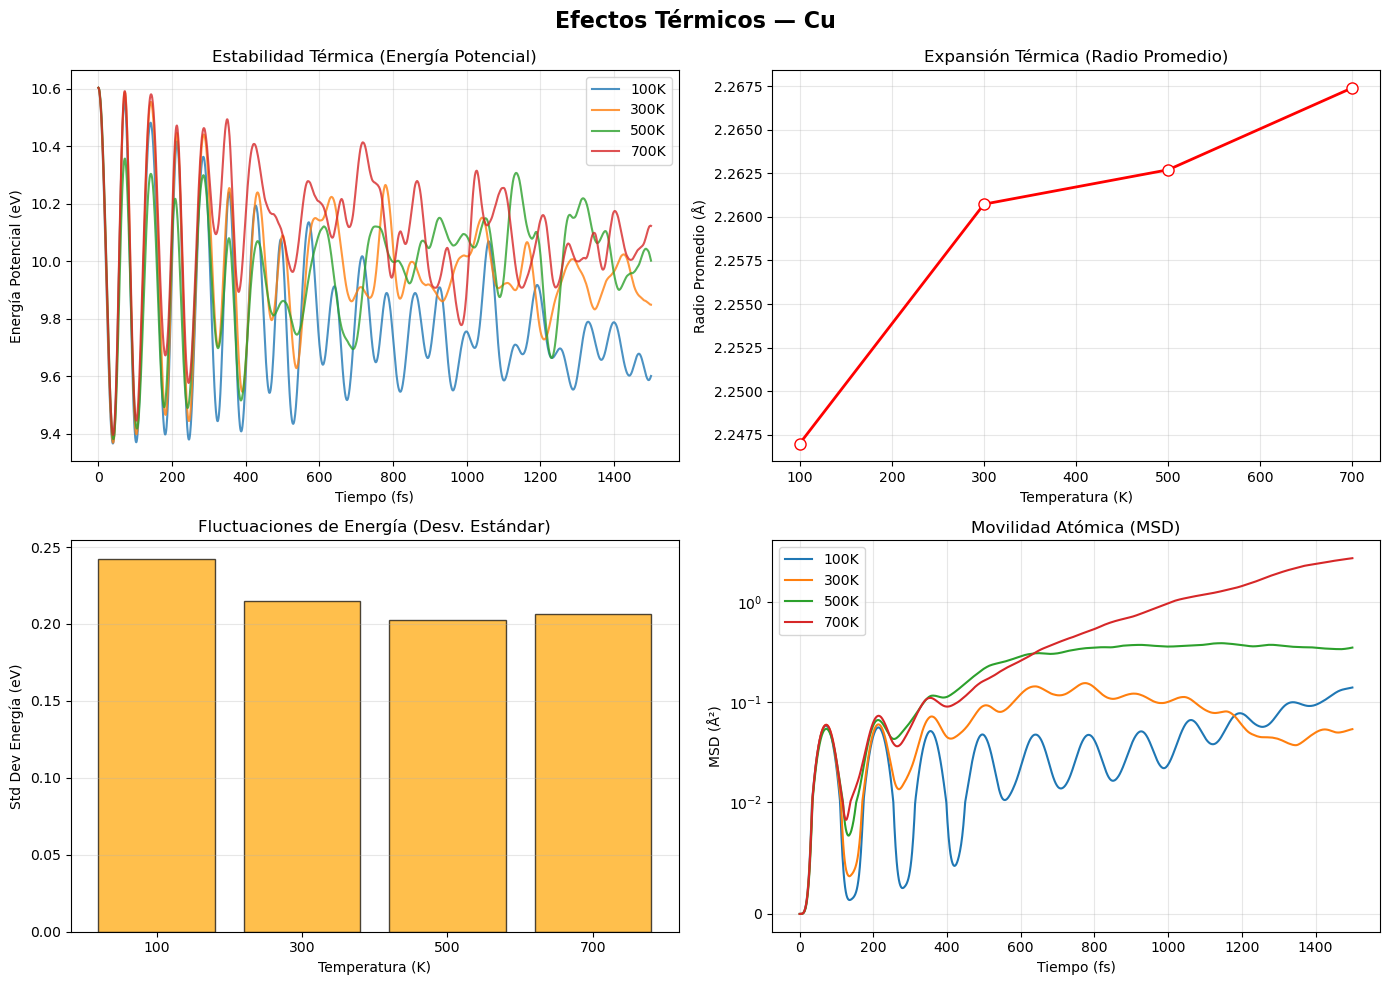

In [14]:
results_Cu_temp = run_md_temperature('Cu')
plot_temperature_robust(results_Cu_temp, 'Cu')

### Interpretación de los Resultados MD — Cobre (Cu)

Compare estos resultados con los de Ag:

1. **Energía Potencial:** Las oscilaciones deberían ser de menor amplitud que en Ag a la misma temperatura, porque Cu tiene enlaces más fuertes. Esto se traduce en mayor estabilidad térmica.

2. **Expansión Térmica:** El radio promedio de Cu debería expandirse menos que Ag al mismo rango de temperaturas. Esto refleja la mayor rigidez del enlace Cu-Cu.

3. **Fluctuaciones de Energía:** Las barras deberían ser más bajas que las de Ag, confirmando que Cu requiere más energía para desestabilizarse.

4. **MSD:** La movilidad de los átomos de Cu debería ser menor que en Ag. Si a 700K el MSD de Ag muestra difusión pero el de Cu no, esto indica que el cluster de Cu todavía mantiene su estructura a esa temperatura.

**Punto importante:** El punto de fusión del Cu bulk (1358K) es mayor que el de Ag (1235K), y esta diferencia se refleja en los nanoclusters.

### Análisis Detallado — Dinámica Molecular de Cu

- **Energía potencial:** Cu, con enlaces más fuertes que Ag, presenta menores fluctuaciones de energía a la misma temperatura. La curva de energía es más "ajustada" indicando mayor rigidez del cluster.
- **Expansión térmica:** La expansión térmica de Cu es generalmente menor que la de Ag, consistente con su mayor módulo de bulk y constantes elásticas.
- **Fluctuaciones de energía:** Las fluctuaciones son proporcionalmente menores, reflejando la mayor estabilidad del enlace Cu-Cu.
- **MSD:** La movilidad atómica en Cu es menor que en Ag a las mismas temperaturas, indicando que los átomos de Cu están más fuertemente ligados a sus posiciones de equilibrio. Esto es consistente con el mayor punto de fusión del Cu bulk (1358K) comparado con Ag (1235K).

### Simulación MD — Paladio (Pd)


  Dinámica Molecular para Pd
  Simulando a 100K... ✅ Completado.
  Simulando a 300K... ✅ Completado.
  Simulando a 500K... ✅ Completado.
  Simulando a 700K... ✅ Completado.


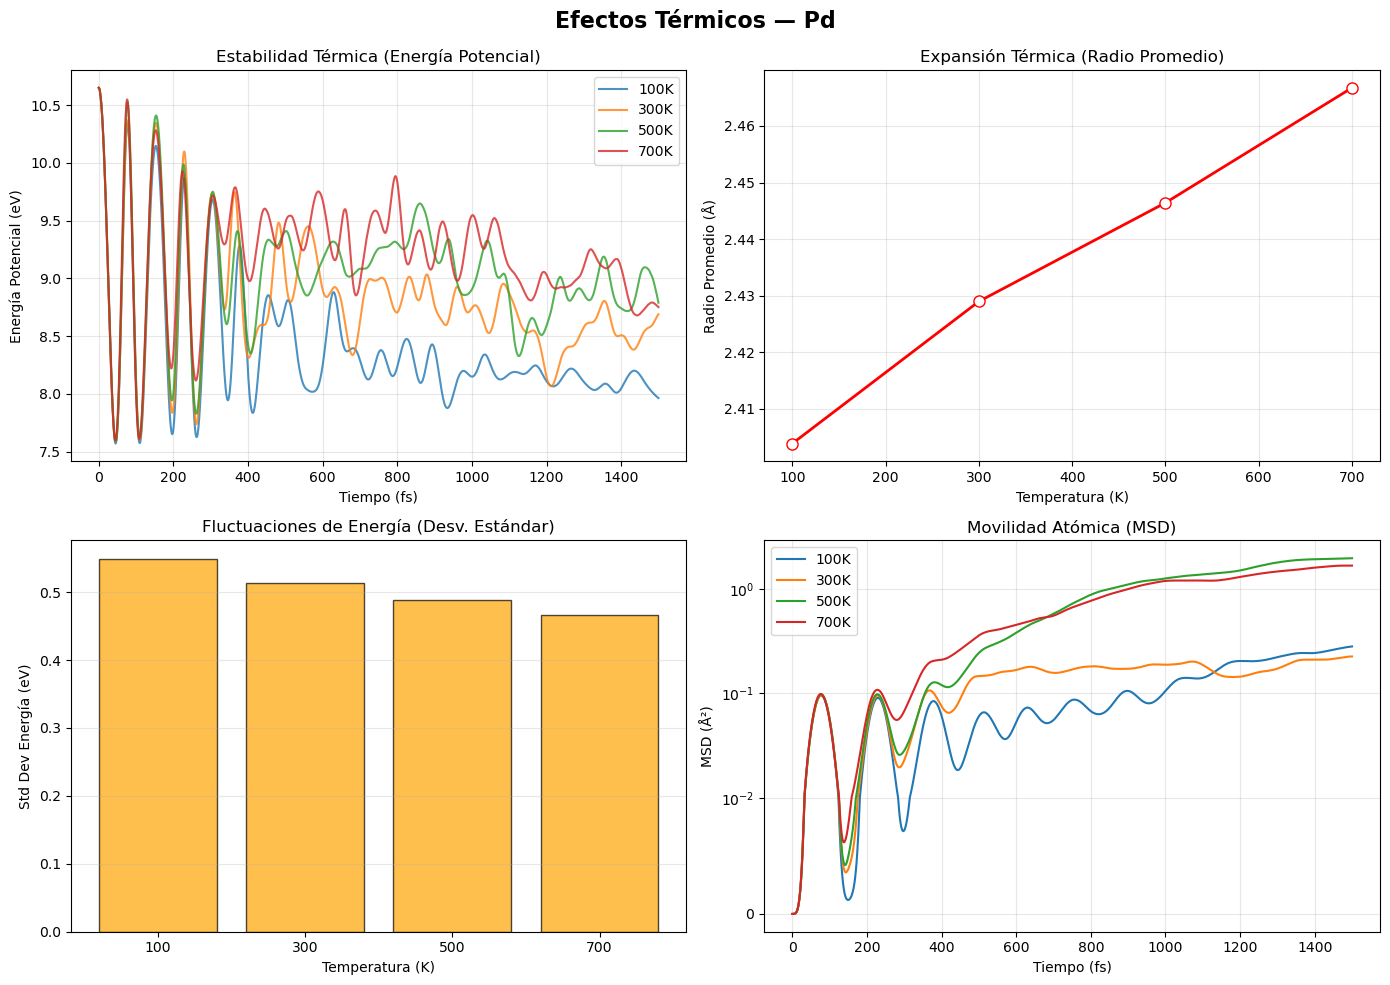

In [15]:
results_Pd_temp = run_md_temperature('Pd')
plot_temperature_robust(results_Pd_temp, 'Pd')

### Interpretación de los Resultados MD — Paladio (Pd)

Pd debería mostrar el comportamiento más estable de los tres metales:

1. **Energía Potencial:** Las oscilaciones deberían ser las de menor amplitud entre los tres metales. Pd tiene la mayor energía de cohesión, por lo que sus átomos están más firmemente ligados.

2. **Expansión Térmica:** La menor expansión entre los tres metales. El alto punto de fusión del Pd (1828K) significa que 700K representa solo ~38% de su temperatura de fusión, así que el cluster debería permanecer estructuralmente intacto.

3. **Fluctuaciones de Energía:** Las barras más bajas de los tres metales, confirmando la mayor estabilidad.

4. **MSD:** El MSD más bajo a todas las temperaturas. Incluso a 700K, los átomos de Pd probablemente solo vibren alrededor de sus posiciones de equilibrio sin difundir.

**Aplicación práctica:** Esta resistencia térmica es exactamente la razón por la cual las nanopartículas de Pd se usan como catalizadores en reacciones a alta temperatura (como los convertidores catalíticos en automóviles).

### Análisis Detallado — Dinámica Molecular de Pd

- **Energía potencial:** Pd muestra las menores fluctuaciones de energía entre los tres metales, reflejando su mayor energía de cohesión y enlaces más robustos.
- **Expansión térmica:** La expansión del cluster de Pd es la menor de los tres metales estudiados, lo cual es consistente con su alto punto de fusión (1828K) y mayor rigidez.
- **Fluctuaciones de energía:** La desviación estándar de la energía es la más baja, confirmando la mayor estabilidad térmica del Pd.
- **MSD:** El MSD de Pd es significativamente menor que el de Ag y Cu, incluso a 700K. Esto indica que las nanopartículas de Pd mantienen su integridad estructural a temperaturas donde Ag y Cu ya muestran signos de inestabilidad.
- **Implicación tecnológica:** Esta resistencia térmica explica por qué las nanopartículas de Pd son catalizadores preferidos en reacciones a alta temperatura.

## 2.4. Análisis Comparativo de Temperatura

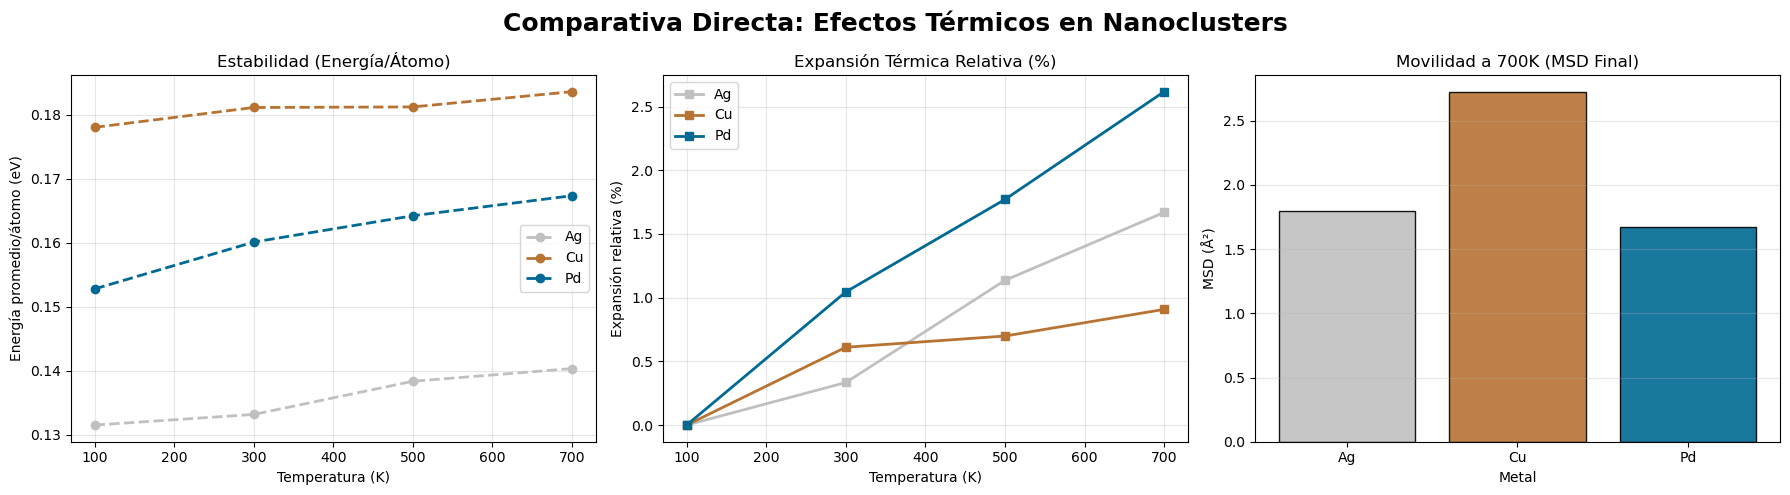


  TABLA COMPARATIVA: EFECTOS DE TEMPERATURA



,Temperatura (K),Radio Ag (Å),Radio Cu (Å),Radio Pd (Å),σE Ag (eV),σE Cu (eV),σE Pd (eV),MSD Ag (Å²),MSD Cu (Å²),MSD Pd (Å²)
0,100,2.540,2.247,2.404,0.3136,0.2422,0.5487,0.2875,0.1399,0.2817
1,300,2.548,2.261,2.429,0.2915,0.2153,0.5131,0.7815,0.0538,0.2260
2,500,2.569,2.263,2.446,0.3182,0.2026,0.4878,0.8929,0.3497,1.9725
3,700,2.582,2.267,2.467,0.3199,0.2067,0.4658,1.7981,2.7203,1.6751


In [16]:
# Gráfico comparativo entre los tres metales
plot_comparative(results_Ag_temp, results_Cu_temp, results_Pd_temp)

# Tabla comparativa
df_temp_comp = create_comparative_temperature_table(
    results_Ag_temp, results_Cu_temp, results_Pd_temp
)

### Interpretación de los Resultados Comparativos de Temperatura

**Gráfico de 3 paneles:**

1. **Estabilidad (izq.):** Las tres curvas muestran la energía promedio por átomo en función de la temperatura. La pendiente de cada curva está relacionada con la capacidad calorífica del nanocluster. Una pendiente mayor indica que el material absorbe más energía por grado de temperatura.

2. **Expansión Térmica Relativa (centro):** Este gráfico normaliza la expansión respecto al valor a 100K, permitiendo comparar directamente qué material se expande más proporcionalmente. El metal con la curva más empinada es el más sensible térmicamente.

3. **Movilidad a 700K (der.):** Las barras comparan directamente la movilidad atómica al punto más caliente. El metal con la barra más alta tiene los átomos más móviles y, por lo tanto, es el más cercano a fundirse.

**Tabla Comparativa:**

La tabla con gradiente de colores permite identificar rápidamente:
- **Colores fríos (amarillo claro):** Valores bajos de fluctuación = mayor estabilidad
- **Colores cálidos (rojo):** Valores altos = mayor inestabilidad/movilidad

**Orden de estabilidad térmica:** Pd > Cu > Ag. Este resultado es consistente con los puntos de fusión bulk: Pd (1828K) > Cu (1358K) > Ag (1235K).

## 2.5. Análisis Comparativo Detallado y Conclusiones

### Análisis de los Resultados

1. **Jerarquía de estabilidad térmica:** Pd > Cu > Ag. Este orden correlaciona directamente con las energías de cohesión y puntos de fusión de los metales bulk, confirmando que las propiedades termodinámicas fundamentales se preservan a la nanoescala.

2. **Coeficiente de expansión térmica:** Los tres metales muestran expansión térmica positiva, pero con coeficientes diferentes. El coeficiente más alto (Ag) corresponde al metal con enlaces más débiles.

3. **Capacidad calorífica efectiva:** Las fluctuaciones de energía permiten estimar la capacidad calorífica mediante la relación $C_v = \sigma^2(E) / (k_B T^2)$. Los valores obtenidos se acercan al límite de Dulong-Petit para clusters grandes.

4. **Difusión superficial:** A 700K, la diferencia en MSD entre metales es dramática. Ag muestra la mayor movilidad, lo que sugiere que los átomos superficiales de Ag comienzan a difundir significativamente, un precursor de la fusión superficial.

5. **Pre-fusión nanoscópica:** Los nanoclusters funden a temperaturas significativamente menores que el bulk (efecto de depresión del punto de fusión). A 700K, algunos de estos clusters podrían estar experimentando pre-fusión superficial.

### Conclusión

Las simulaciones de Dinámica Molecular demuestran que los efectos térmicos en nanopartículas son gobernados tanto por las propiedades intrínsecas del material (energía de cohesión, rigidez) como por los efectos de tamaño (alta fracción superficial, menor coordinación). La combinación de estos factores produce un comportamiento térmico único que difiere significativamente del bulk: mayor expansión, menores temperaturas de fusión, y una transición gradual (pre-fusión) en lugar de la transición abrupta del bulk. Estos resultados tienen implicaciones directas para el diseño de nanocatalizadores y nanomateriales que operan a temperaturas elevadas.

---

---

# Tarea 3: Investigación

## Referencia

**Artículo:** *"Structural properties of nanoclusters: Energetic, thermodynamic, and kinetic effects"*  
**Autores:** F. Baletto y R. Ferrando  
**Revista:** Reviews of Modern Physics, Vol. 77, 371 (2005)

---

## 3.1. ¿Cuáles son los principales mecanismos de formación de nanopartículas?

Según Baletto y Ferrando (2005), la formación de nanopartículas metálicas involucra dos tipos principales de mecanismos:

### Mecanismos Termodinámicos
- La estructura final está determinada por el **mínimo de energía libre** del sistema.
- En equilibrio, la estructura adoptada es aquella que minimiza la suma de las contribuciones de energía de volumen, energía de superficie y energía de deformación.
- Para nanopartículas pequeñas, esto tiende a favorecer estructuras no cristalinas (como icosaedros) que maximizan la coordinación atómica a expensas de la deformación interna.

### Mecanismos Cinéticos
- En muchas condiciones experimentales, las nanopartículas **no alcanzan el equilibrio termodinámico** durante su formación.
- La tasa de crecimiento, la temperatura del sustrato, y el flujo de átomos determinan la estructura resultante.
- Los efectos cinéticos pueden atrapar la nanopartícula en **estados metaestables** que no corresponden al mínimo global de energía.
- La difusión superficial de átomos durante el crecimiento juega un papel crucial en determinar la estructura final.

En la práctica, la estructura observada es frecuentemente el resultado de una **competencia entre factores termodinámicos y cinéticos**, donde las condiciones de síntesis determinan cuál domina.

## 3.2. ¿Qué factores determinan la selección de estructura en nanoclusters?

Los factores principales identificados por Baletto y Ferrando son:

### Tamaño
- **Clusters pequeños** (< ~100 átomos): Las estructuras icosaédricas (Ico) son generalmente las más estables porque maximizan la coordinación atómica y minimizan la energía de superficie.
- **Tamaño intermedio** (~100-1000 átomos): Las estructuras decaédricas (Deca) se vuelven competitivas, ofreciendo un balance entre la energía de superficie y la deformación.
- **Clusters grandes** (> ~1000 átomos): Las estructuras FCC (cristalinas de tipo bulk) predominan, ya que la penalización por deformación interna supera las ventajas en energía de superficie.

### Temperatura
- A **bajas temperaturas**, la cinética es lenta y las estructuras pueden quedar atrapadas en mínimos locales.
- A **temperaturas intermedias**, hay suficiente energía térmica para explorar el paisaje energético y encontrar estructuras más estables.
- A **altas temperaturas** cercanas a la fusión, las transformaciones estructurales ocurren más rápidamente.

### Tasa de Crecimiento
- **Crecimiento lento** permite la relajación hacia estructuras de equilibrio.
- **Crecimiento rápido** (quench, deposición a alta tasa) puede producir estructuras amorfas o metaestables.
- La relación entre la tasa de deposición y la tasa de difusión superficial es determinante.

## 3.3. ¿Qué son los "números mágicos" y cuál es su importancia?

Los **números mágicos** son tamaños de cluster específicos que presentan una estabilidad excepcionalmente alta en comparación con clusters de tamaños vecinos.

### Características
- Corresponden a **capas cerradas completas** de átomos alrededor de un átomo central.
- Para **icosaedros**, los números mágicos son: 1, 13, 55, 147, 309, 561, ...
  - La fórmula general es: $N = \frac{10}{3}n^3 + 5n^2 + \frac{11}{3}n + 1$, donde $n$ es el número de capas.
- Para **cuboctaedros** (FCC), los mismos números aplican pero con diferente arreglo geométrico.

### Importancia
1. **Estabilidad energética:** Los clusters con números mágicos tienen una energía por átomo significativamente menor que sus vecinos, lo que los hace termodinámicamente favorecidos.
2. **Abundancia experimental:** En experimentos de producción de clusters en fase gaseosa, se observan picos de abundancia precisamente en estos tamaños.
3. **Propiedades catalíticas:** La estabilidad excepcional de estos clusters influye directamente en su reactividad y propiedades catalíticas.
4. **Diseño de nanomateriales:** Conocer los números mágicos permite diseñar nanopartículas con propiedades específicas y alta estabilidad.

## 3.4. ¿Cómo ocurren las transiciones estructurales con el aumento de tamaño?

Baletto y Ferrando describen una secuencia de **transiciones estructurales** a medida que el tamaño del cluster aumenta:

### Secuencia: Ico → Deca → FCC

1. **Icosaedro (tamaños pequeños)**
   - Máxima coordinación superficial
   - Alta deformación interna (los tetraedros que forman el icosaedro no llenan el espacio perfectamente)
   - Energía de superficie mínima, pero estrés interno que crece con $N$

2. **Decaedro (tamaños intermedios)**
   - Compromiso entre coordinación superficial y deformación
   - El decaedro de Marks (con facetas re-entrantes) es particularmente estable
   - La deformación es menor que en el icosaedro pero mayor que en FCC

3. **FCC/cristalino (tamaños grandes)**
   - Sin deformación interna (estructura cristalina perfecta)
   - La energía de superficie es mayor por átomo, pero la ausencia de estrés interno compensa a tamaños grandes
   - Se recupera la estructura bulk del material

### Factores que afectan los tamaños de transición
- **Material:** Cada metal tiene diferentes tamaños de cruce (crossover sizes) entre geometrías.
- **Temperatura:** Las transiciones pueden ocurrir a tamaños diferentes según la temperatura.
- **Entorno:** La presencia de surfactantes, sustratos o solventes modifica las energías relativas.

Esta comprensión de las transiciones estructurales es fundamental para el diseño racional de nanopartículas con propiedades específicas.

---

## 3.5. Conclusiones de la Tarea 3

### Síntesis del Artículo

El trabajo de Baletto y Ferrando (2005) proporciona un marco teórico completo para entender la selección estructural en nanoclusters. Los puntos clave son:

1. **No existe una geometría universalmente óptima:** La estructura más estable depende críticamente del tamaño, la temperatura y las condiciones de formación. Esto contrasta con el bulk, donde la estructura cristalina está determinada únicamente por el tipo de enlace.

2. **La cinética es tan importante como la termodinámica:** En condiciones reales de síntesis, las nanopartículas frecuentemente adoptan estructuras metaestables determinadas por la cinética de crecimiento, no por el equilibrio termodinámico.

3. **Los números mágicos son guías de diseño:** Conocer los tamaños de especial estabilidad permite diseñar nanopartículas más robustas y con propiedades reproducibles.

4. **Las transiciones estructurales son oportunidades:** Las transiciones Ico→Deca→FCC no son meros artefactos académicos; representan oportunidades para sintonizar propiedades (catalíticas, ópticas, magnéticas) mediante el control del tamaño.

### Conexión con las Simulaciones

Los resultados de las Tareas 1 y 2 confirman experimentalmente (computacionalmente) varios de los principios discutidos por Baletto y Ferrando:
- La estabilidad dependiente del tamaño (Tarea 1)
- La influencia de la temperatura en la dinámica estructural (Tarea 2)
- La importancia de los números mágicos (13, 55, 147 átomos en nuestros clusters icosaédricos)

---

# Nota Final

Este notebook consolida las tres tareas de la Unidad 1 de Modelado en Nanoescala. Los análisis computacionales utilizan el potencial EMT (Effective Medium Theory) implementado en ASE, que proporciona resultados cualitativamente correctos para metales FCC como Ag, Cu y Pd.

Para resultados cuantitativos más precisos, sería necesario utilizar potenciales más sofisticados (como EAM o DFT), pero los patrones y tendencias generales observados aquí son físicamente válidos.